In [ ]:
from aoespy import *
import xarray as xr
import ecco_v4_py as ecco
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
from glob import glob
import os


#

/home6/afahad/.local/lib/python3.9/site-packages/aoespy.py:19: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [ ]:
def readmit(exp='GEOSMIT35_ctrl',loc='/nobackupp27/afahad/exp/IAU_exp/',file='state_2d_set1',var=1,start_date='20050501',nfiles=-1,freq='D',nz=50, nf=11, ni=90, nj=90, ntile=13,expdir='../mit_output/'):
    
    input_dir = '/nobackupp27/afahad/GEOSMITgcmFiles/mit_input_llc90_02'
    input_file = 'bathy_eccollc_90x50_min2pts.bin'
    os.chdir(loc+exp+'/plot')
    pdir='../plots_CLIM/ocean_mit/'
    vdir='/nobackupp27/afahad/mit_diag/'
    try:
        os.system('mkdir -p '+pdir)
    except:
        None

    bathy = ecco.read_llc_to_tiles(input_dir, input_file)

    ecco_grid = ecco.load_ecco_grid_nc(input_dir, 'ECCO-GRID.nc')


    
    restarts='../restarts/'

    os.chdir(expdir)
    files=np.array(sorted(glob(file+'*.data'))[0:nfiles])
    time=pd.date_range(start_date,periods=len(files),freq=freq)
    
    djf_files=files

    nt=len(time); 

    ndjf=len(djf_files)

    theta_djf=np.zeros((ndjf,nz,ntile,nj,ni)); theta_djf[:]=np.nan
    
    print('reading files')
    for i in range(ndjf):
        print(djf_files[i])
        data=ecco.read_llc_to_tiles(expdir, djf_files[i], nk=-1,nl=-1)
        print(data.shape)
        data=np.reshape(data, (nf,nz,ntile,nj,ni))
        theta_djf[i,:,:,:]=data[var,:,:,:,:]
    return (theta_djf, time)
    
def llc2grd(theta_djf,nz=50):
    input_dir = '/nobackupp27/afahad/GEOSMITgcmFiles/mit_input_llc90_02'
    input_file = 'bathy_eccollc_90x50_min2pts.bin'
    ecco_grid = ecco.load_ecco_grid_nc(input_dir, 'ECCO-GRID.nc')
    theta_djf_all=np.zeros(theta_djf.shape)
    theta_djf_all[:]=theta_djf

    new_grid_delta_lat = 1
    new_grid_delta_lon = 1

    new_grid_min_lat = -90
    new_grid_max_lat = 91

    new_grid_min_lon = -180
    new_grid_max_lon = 180

    new_lat=np.arange(-90,91,1); nlat=len(new_lat)
    new_lon=np.arange(-180,180,1); nlon=len(new_lon)

    tt=len(theta_djf)
    theta_djf_alli=np.zeros((tt,nz,nlat,nlon))

    for i in range(tt):
        for j in range(nz):

            new_grid_lon_centers, new_grid_lat_centers,\
            new_grid_lon_edges, new_grid_lat_edges,\
            theta_djf_alli[i,j,:,:] =\
                    ecco.resample_to_latlon(ecco_grid.XC, \
                                            ecco_grid.YC, \
                                            theta_djf_all[i,j,:,:,:],\
                                            new_grid_min_lat, new_grid_max_lat, new_grid_delta_lat,\
                                            new_grid_min_lon, new_grid_max_lon, new_grid_delta_lon,\
                                            fill_value = np.NaN, \
                                            mapping_method = 'nearest_neighbor',
                                            radius_of_influence = 120000)
    return (np.squeeze(theta_djf_alli), new_lon, new_lat)


In [266]:
ME506, time=readmit('GEOSMIT_ME0506',var=10,nz=1,nfiles=61,nf=11,freq='D',start_date='20050506')
#ME506=ME506[:,0:1,:,:,:]
ME506,lon,lat=llc2grd(ME506,nz=1)

load_binary_array: loading file /nobackupp27/afahad/GEOSMITgcmFiles/mit_input_llc90_02/bathy_eccollc_90x50_min2pts.bin
load_binary_array: data array shape  (1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
reading files
state_2d_set1.0000000060.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000000060.data
load_binary_array: loading all 2D records.  nk = 11
load_binary_array: data array shape  (11, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (11, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (11, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(11, 13, 90, 90)
state_2d_set1.0000000252.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000000252.data
load_binary_arra

llc_faces_to_tiles: data_tiles shape  (11, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(11, 13, 90, 90)
state_2d_set1.0000003324.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000003324.data
load_binary_array: loading all 2D records.  nk = 11
load_binary_array: data array shape  (11, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (11, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (11, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(11, 13, 90, 90)
state_2d_set1.0000003516.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000003516.data
load_binary_array: loading all 2D records.  nk = 11
load_binary_array: data array shape  (11, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (11, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (11, 13, 90, 90)
llc_faces_to_

load_binary_array: loading all 2D records.  nk = 11
load_binary_array: data array shape  (11, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (11, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (11, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(11, 13, 90, 90)
state_2d_set1.0000009660.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000009660.data
load_binary_array: loading all 2D records.  nk = 11
load_binary_array: data array shape  (11, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (11, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (11, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(11, 13, 90, 90)
state_2d_set1.0000009852.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000009852.data
load_binary_array: loading all 2D records.  nk = 11
load_binary_arra

In [267]:
# RP506, tiRP=readmit('GEOSMIT_RP0506',var=1,nz=1,nfiles=61,nf=11,freq='D',start_date='20050506')
# #RP506=RP506[:,0:1,:,:,:]
# RP506,lon,lat=llc2grd(RP506,nz=1)

In [268]:
ds = xr.Dataset(
    {
        "ME506": (["time", "lat", "lon"], ME506)
    },
    coords={
        "time": time,
        "lat": lat,
        "lon": lon
    }
)

ME506=ds.ME506.sel(time=slice('2005-05','2005-06'))

In [269]:
# ds = xr.Dataset(
#     {
#         "RP506": (["time", "lat", "lon"], RP506),
#         "ME506": (["time", "lat", "lon"], ME506)
#     },
#     coords={
#         "time": time,
#         "lat": lat,
#         "lon": lon
#     }
# )

# ME506=ds.ME506.sel(time=slice('2005-05','2005-06'))

# RP506=ds.RP506.sel(time=slice('2005-05','2005-06'))

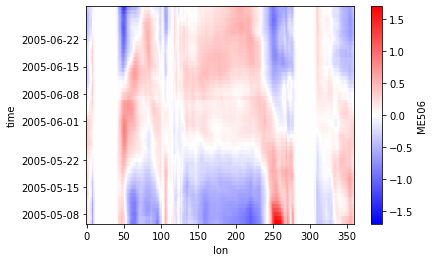

In [270]:
cp=ME506.sel(time=slice('2005-05-01','2005-06-30'))
cp = cp.assign_coords(lon=np.where(cp.lon < 0, cp.lon + 360, cp.lon)).sortby('lon')
ss=slice(-5,5)
(cp.sel(lat=ss)-cp.sel(lat=ss).mean(dim='time')).sel(lon=slice(-180,360)).mean(dim='lat').plot(cmap='bwr')

In [246]:
ticks=[]

for i in range(len(ME506.time)):
    ticks=append(ticks,str(ME506.time.data[i])[5:10])

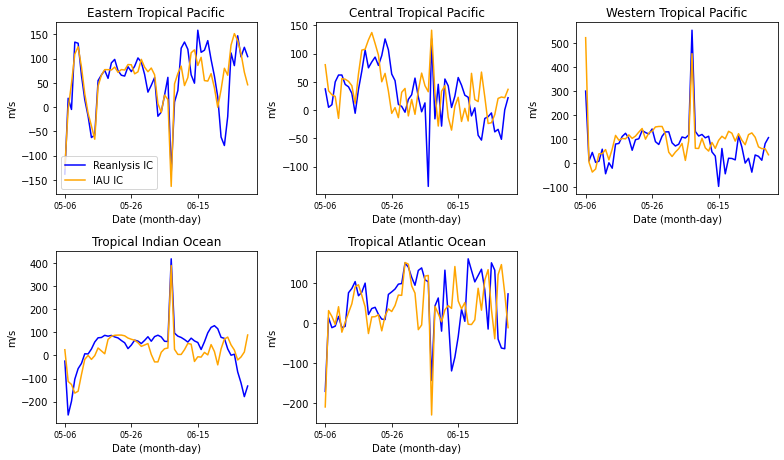

In [195]:

# x1=-115
# x2=-115
# y1=5
# y2=5

# x1=-79
# x2=-79
# y1=-5
# y2=-5


x1=-127
x2=-127
y1=7
y2=7


plt.figure(figsize=(11,6.5))
plt.subplot(2,3,1)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Eastern Tropical Pacific')
plt.xticks(arange(len(ticks))[::20],ticks[::20],fontsize=8);
plt.legend(['Reanlysis IC', 'IAU IC'])
plt.xlabel('Date (month-day)')
plt.ylabel('m/s')


x1=-178
x2=-178
y1=-5
y2=-5

plt.subplot(2,3,2)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Central Tropical Pacific')
plt.xticks(arange(len(ticks))[::20],ticks[::20],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('m/s')

x1=136
x2=137
y1=3
y2=4

plt.subplot(2,3,3)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Western Tropical Pacific')
plt.xticks(arange(len(ticks))[::20],ticks[::20],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('m/s')

x1=89
x2=92
y1=7
y2=8



plt.subplot(2,3,4)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Tropical Indian Ocean')
plt.xticks(arange(len(ticks))[::20],ticks[::20],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('m/s')

x1=-39
x2=-38
y1=7
y2=8



plt.subplot(2,3,5)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Tropical Atlantic Ocean')
plt.xticks(arange(len(ticks))[::20],ticks[::20],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('m/s')

x1=90
x2=91
y1=23
y2=25

# plt.subplot(2,3,6)
# # plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# # plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

# plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# #plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

# plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
# #plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
# plt.title('Indian Monsoon')
# plt.xticks(arange(len(ticks))[::20],ticks[::20],fontsize=8);
# plt.xlabel('Date (month-day)')
# plt.ylabel('m/s')

x1=32
x2=35
y1=-1
y2=2


pdir='/nobackupp27/afahad/scripts/initialization_shock/'
plt.tight_layout()
#plt.savefig(pdir+'spike_wvel.png',dpi=150)

Text(0, 0.5, 'm/s')

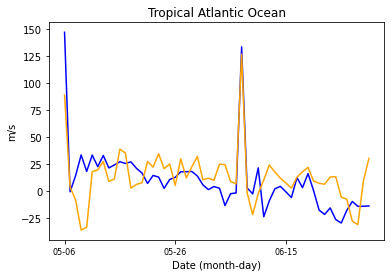

In [197]:
x1=100
x2=101
y1=2
y2=3

# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Tropical Atlantic Ocean')
plt.xticks(arange(len(ticks))[::20],ticks[::20],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('m/s')

In [198]:
# plt.figure(figsize=(11,8.5))
# clf=arange(30,30.51,.1)
# cmap='Blues_r'
# cmap='Reds'
# plt.subplot(2,3,1)
# (cp)[0,:,:].sel(lat=slice(-20,20),lon=slice(-180,180)).plot.imshow(levels=clf,cmap=cmap)
# plt.subplot(2,3,2)
# (cp)[1,:,:].sel(lat=slice(-20,20),lon=slice(-180,180)).plot(levels=clf,cmap=cmap)
# plt.subplot(2,3,3)
# (cp)[2,:,:].sel(lat=slice(-20,20),lon=slice(-180,180)).plot(levels=clf,cmap=cmap)
# plt.subplot(2,3,4)
# (cp)[3,:,:].sel(lat=slice(-20,20),lon=slice(-180,180)).plot.imshow(levels=clf,cmap=cmap)
# plt.subplot(2,3,5)
# (cp)[4,:,:].sel(lat=slice(-20,20),lon=slice(-180,180)).plot(levels=clf,cmap=cmap)

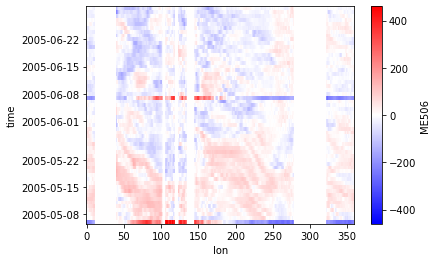

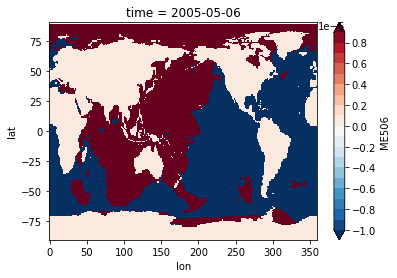

In [200]:
cp[0,:,:].plot(levels=arange(-1,1,.1)*1e-6)